In [1]:

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.backends.cudnn.benchmark = True

Using device: cuda


In [2]:
train_dir = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/train/train"
test_dir  = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/test/test"

In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)   # small shift
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
    [0.485, 0.456, 0.406],
    [0.229, 0.224, 0.225]
)
])

In [4]:
class CleanDataset(datasets.ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform)

        # ❌ Remove ALL H classes (train + test)
        self.samples = [
            s for s in self.samples
            if not os.path.basename(os.path.dirname(s[0])).lower().startswith("h")
        ]

        self.imgs = self.samples

        # ✅ Keep only leukemia classes
        self.classes = [
            cls for cls in self.classes
            if not cls.lower().startswith("h")
        ]

        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        # rebuild samples properly
        new_samples = []
        new_targets = []

        for path, _ in self.samples:
            class_name = os.path.basename(os.path.dirname(path))
            
            # map class name to index
            for cls_name in self.classes:
                if cls_name.lower().split()[0] in class_name.lower():
                    label = self.class_to_idx[cls_name]
                    new_samples.append((path, label))
                    new_targets.append(label)
                    break

        self.samples = new_samples
        self.targets = new_targets

In [5]:
train_dataset = CleanDataset(train_dir, transform=train_transforms)
test_dataset  = CleanDataset(test_dir, transform=test_transforms)

print(train_dataset.classes)
print(len(train_dataset.classes))
print(len(train_dataset))
print(max(train_dataset.targets))
print(test_dataset.classes)

['all train', 'aml train', 'cll train', 'cml']
4
12000
3
['ALL TEST-20230225T082325Z-001', 'AML TEST-20230225T082630Z-001', 'CLL TEST-20230225T082851Z-001', 'CML TEST-20230225T083148Z-001']


In [6]:

# loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True)
# val_loader   = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [7]:
from torchvision.models import EfficientNet_B0_Weights

model = models.efficientnet_b0(
    weights=EfficientNet_B0_Weights.IMAGENET1K_V1
)

#unfreeze backbone
for param in model.features[:-5].parameters():
    param.requires_grad = False

for param in model.features[-5:].parameters():
    param.requires_grad = True
num_classes = len(train_dataset.classes)

model.classifier[1] = nn.Sequential(
    nn.BatchNorm1d(model.classifier[1].in_features),
    nn.Dropout(0.4),
    nn.Linear(model.classifier[1].in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 141MB/s]


In [8]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# better LR
optimizer = torch.optim.Adam([
    {"params": model.features[-5:].parameters(), "lr": 3e-5},
    {"params": model.classifier.parameters(), "lr": 3e-4}
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5,
    min_lr=1e-6
)

In [9]:
class EarlyStopping:
    def __init__(self, patience=7):
        self.patience = patience
        self.best_loss = float('inf')
        self.counter = 0

    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

In [10]:
def train_model(model, train_loader, val_loader, epochs=25):
    scaler = torch.amp.GradScaler("cuda")
    early_stopping = EarlyStopping(patience=9)

    best_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        print(f"\n📌 Epoch [{epoch+1}/{epochs}]")

        loop = tqdm(train_loader, desc="Training")

        for images, labels in loop:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

            # ✅ TRAIN ACCURACY
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(
                loss=loss.item(),
                acc=100 * correct / total
            )

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        # 🔍 VALIDATION
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        model.eval()
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total

        print(f"✅ Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"📊 Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # 🎯 Scheduler
        scheduler.step(val_loss)
        print(f"📉 Current LR: {optimizer.param_groups[0]['lr']:.6f}")

        # 💾 Save best model
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
            print("💾 Saved Best Model")

        # ⛔ Early stopping
        if early_stopping.step(val_loss):
            print("⛔ Early stopping triggered")
            break

In [11]:
from torch.utils.data import Subset
import random

def get_balanced_subset(dataset, samples_per_class=200):
    class_indices = {i: [] for i in range(len(dataset.classes))}

    for idx, (_, label) in enumerate(dataset.samples):
        class_indices[label].append(idx)

    selected_indices = []
    for cls in class_indices:
        selected_indices += random.sample(class_indices[cls], samples_per_class)

    return Subset(dataset, selected_indices)

val_subset = get_balanced_subset(test_dataset, samples_per_class=200)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=4)

In [12]:
train_model(model, train_loader, val_loader, epochs=40)


📌 Epoch [1/40]


Training:   0%|          | 0/375 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Training: 100%|██████████| 375/375 [14:08<00:00,  2.26s/it, acc=84.8, loss=0.321]


✅ Train Loss: 0.5415 | Train Acc: 84.83%
📊 Val Loss: 0.7837 | Val Acc: 78.12%
📉 Current LR: 0.000030
💾 Saved Best Model

📌 Epoch [2/40]


Training: 100%|██████████| 375/375 [13:35<00:00,  2.17s/it, acc=94.7, loss=0.268]


✅ Train Loss: 0.3458 | Train Acc: 94.71%
📊 Val Loss: 0.7042 | Val Acc: 80.12%
📉 Current LR: 0.000030
💾 Saved Best Model

📌 Epoch [3/40]


...

✅ Train Loss: 0.2159 | Train Acc: 99.77%
📊 Val Loss: 0.5207 | Val Acc: 85.12%
📉 Current LR: 0.000008

📌 Epoch [28/40]


Training: 100%|██████████| 375/375 [13:19<00:00,  2.13s/it, acc=99.9, loss=0.212]


✅ Train Loss: 0.2146 | Train Acc: 99.87%
📊 Val Loss: 0.5463 | Val Acc: 85.50%
📉 Current LR: 0.000004

📌 Epoch [29/40]


Training: 100%|██████████| 375/375 [13:16<00:00,  2.12s/it, acc=99.9, loss=0.209]


✅ Train Loss: 0.2149 | Train Acc: 99.87%
📊 Val Loss: 0.5226 | Val Acc: 85.75%
📉 Current LR: 0.000004
⛔ Early stopping triggered


In [13]:
def test_model(model, test_loader):
    # 🔥 Load best model
    model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))

    model.to(device)
    model.eval()

    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"\n🎯 Test Accuracy: {accuracy:.2f}%")

    return all_labels, all_preds
    # Run test
y_true, y_pred = test_model(model, test_loader)

# Classification report
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=test_dataset.classes
))

Testing: 100%|██████████| 125/125 [04:16<00:00,  2.05s/it]



🎯 Test Accuracy: 87.62%
                               precision    recall  f1-score   support

ALL TEST-20230225T082325Z-001       0.91      0.65      0.76      1000
AML TEST-20230225T082630Z-001       0.79      0.93      0.85      1000
CLL TEST-20230225T082851Z-001       0.88      0.92      0.90      1000
CML TEST-20230225T083148Z-001       0.95      1.00      0.97      1000

                     accuracy                           0.88      4000
                    macro avg       0.88      0.88      0.87      4000
                 weighted avg       0.88      0.88      0.87      4000



In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(y_true, y_pred, class_names):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred)

    # Ensure class names match matrix size
    if len(class_names) != cm.shape[0]:
        print("⚠️ Class mismatch detected, fixing labels...")
        class_names = [str(i) for i in range(cm.shape[0])]

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()

Testing: 100%|██████████| 125/125 [04:17<00:00,  2.06s/it]



🎯 Test Accuracy: 87.62%


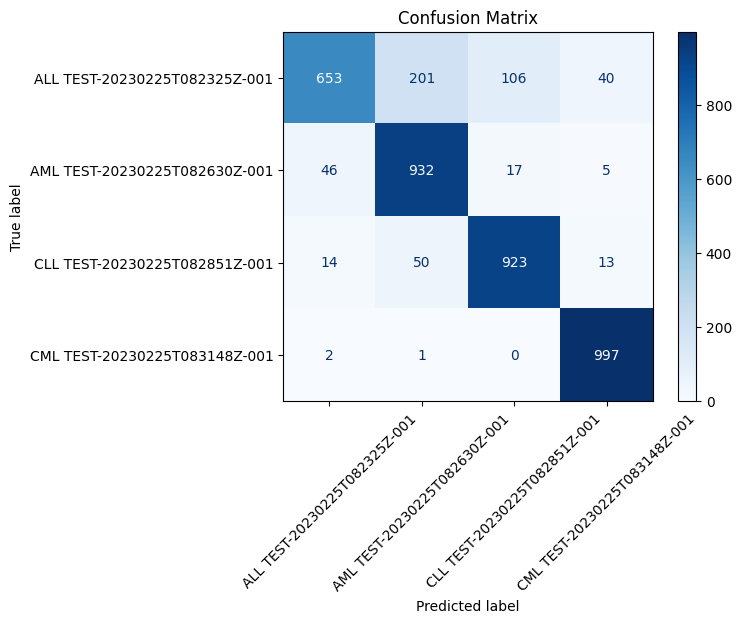

In [15]:
y_true, y_pred = test_model(model, test_loader)

plot_confusion_matrix(y_true, y_pred, test_dataset.classes)